In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import scipy
import pandas as pd
import sys
module_path = os.path.abspath(os.path.join('C:\Latex_HDD\Scripty'))
if module_path not in sys.path:
    sys.path.append(module_path)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.ticker as ticker
import importlib
import os
from glob import glob



import elchem_handy_V1 as pyfai
import copy
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from scipy.signal import savgol_filter

import impedance
from impedance.models.circuits import Randles, CustomCircuit
from impedance.models.circuits.fitting import circuit_elements, get_element_from_name, extract_circuit_elements, circuit_fit
from impedance.models.circuits.fitting import check_and_eval

from itertools import zip_longest

# import ipywidgets as widgets
# from ipywidgets import HBox, VBox
# from IPython.display import display

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (8, 8),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large',
         'figure.autolayout' : True}
pylab.rcParams.update(params)


## Set your parameters

In [8]:
path_OUT=r'C:\Latex_HDD\Clanek_AEM\RDE_exports'
 

if not os.path.exists(path_OUT):
    os.makedirs(path_OUT)
    
# area for normalization

area=0.19634

## Define and load your samples

In [11]:
sample1=r'C:\Latex_HDD\Clanek_AEM\RDE_testing_data'
# sample2=r'D:\Science\PEMWE research\2024_new_naming\048 III Racek, 50nm Ir on plain in 0,5sccm O2'
# sample3=r'D:\Science\PEMWE research\2024_new_naming\053 III Racek, 50nm Ir on plain in 1sccm O2'
# sample4=r'D:\Science\PEMWE research\2024_new_naming\060 III Racek, 50nm Ir on plain in 2sccm O2'

data1,flist1,fname1= pyfai.loadFilesMPT(folder=sample1,wild ='*')
# data2,flist2,fname2= pyfai.loadFilesMPT(folder=sample2,wild ='*')
# data3,flist3,fname3= pyfai.loadFilesMPT(folder=sample3,wild ='*')
# data4,flist4,fname4= pyfai.loadFilesMPT(folder=sample4,wild ='*')

# pick the datasets you want to plot
data_samples = [data1]
fname_samples=[fname1]

for i,item in enumerate(fname_samples):
    print('Sample nr: ', i+1)
    print(pyfai.dayproc(item))

Sample nr:  1
['Day 3 procedures: 01', 'Day 4 procedures: 01', 'Day 5 procedures: 01', 'Day 6 procedures: 01', 'Day 8 procedures: 01']


## Select what you want to plot for each sample

['III_Day1 _procedure1_03_SV.mpt', 'III_Day2_procedure1_03_SV.mpt', 'III_Day3_procedure1_03_SV.mpt']
['III_Day1 _procedure1_03_SV.mpt']
['III_Day1_procedure1_03_SV.mpt']
['III_Day4_procedure1_03_SV.mpt']
[['0.1 Day 1', '0.1 Day 2', '0.1 Day 3'], 'MEA 0.5 sccm O2', 'MEA 1 sccm O2', 'MEA 2 sccm O2'] ['blue', 'red', 'green', 'black'] [4.62, 4.62, 4.62, 4.62]


<IPython.core.display.Javascript object>


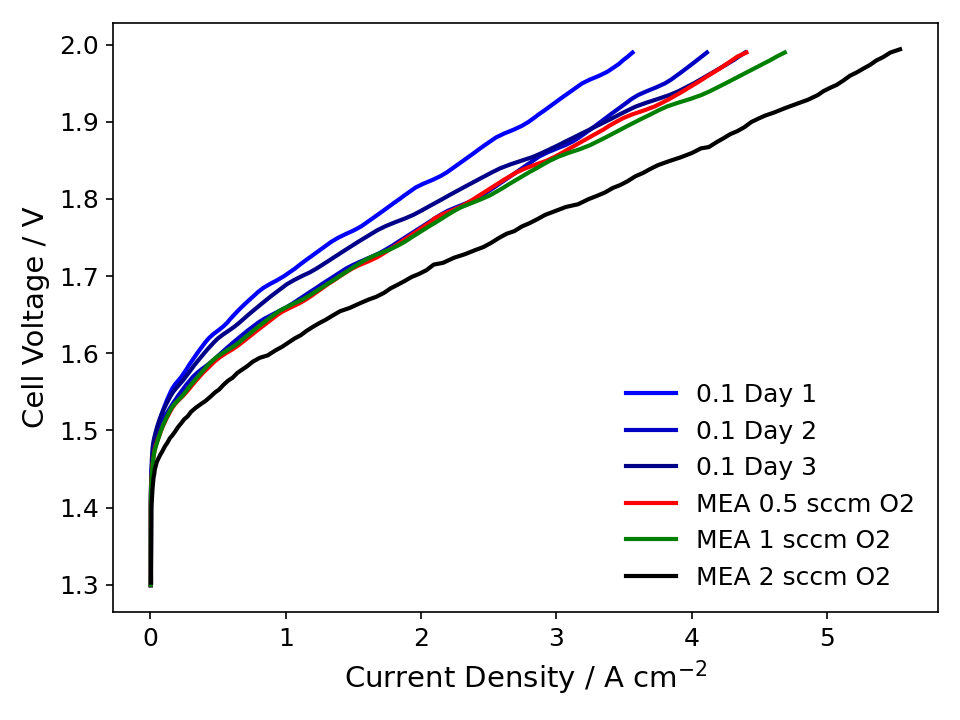

In [10]:
%matplotlib notebook
name='IV_curves_O'

## common parameters. To EIS_E : [1.3, 1.35,1.5]

base_params = {
    'procedure': 'SV',
    'typen': [-6, -4],
    'EIS_E': 'all',
    'fR': [3E4, 1]
}

## free parameters

user_params_list = [
    {'label': ['0.1 Day 1','0.1 Day 2', '0.1 Day 3'], 'color': 'blue',
     'day':  [1,2,3], 'loop': [1], 'proc_nr' : [1,2], 'seq': 'all', 'S': area},
    
    {'label': 'MEA 0.5 sccm O2', 'color': 'red',
     'day':  [1], 'loop': [1], 'proc_nr' : [1], 'seq': 'all', 'S': area},
    
    {'label': 'MEA 1 sccm O2', 'color': 'green',
     'day':  [1], 'loop': [1], 'proc_nr' : [1], 'seq': 'all', 'S': area},
    
    {'label': 'MEA 2 sccm O2', 'color': 'black',
     'day':  [4], 'loop': [1], 'proc_nr' : [1], 'seq': 'all', 'S': area}
]

## Plot all days

# user_params_list = [
#     {'label': 'MEA 0.1 sccm O2', 'color': 'blue',
#      'day':  'all', 'loop': [1], 'seq': 'all', 'S': area},
    
#     {'label': 'MEA 0.5 sccm O2', 'color': 'red',
#      'day': 'all', 'loop': [1], 'seq': 'all', 'S': area},
    
#     {'label': 'MEA 1 sccm O2', 'color': 'green',
#      'day': 'all', 'loop': [1], 'seq': 'all', 'S': area},
    
#     {'label': 'MEA 2 sccm O2', 'color': 'black',
#      'day':  'all', 'loop': [1], 'seq': 'all', 'S': area}
# ]

plot_params = {
    'title_fontsize': 16,
    'axis_label_fontsize': 14,
    'legend_fontsize': 12,
    'tick_fontsize': 12,
#    'x_range': [0, 5],
#    'y_range': [0, 2],
#    'x_ticks': np.linspace(0, 5, 6),
#    'y_ticks': np.linspace(0, 2, 5),
    'min_size' : 1000, 
    'linewidth' : 2,
    'front_gap' : 1, ## removes x data points from the beginning. For loope, the length of the loop must be added: 361
    'back_gap' :-1 ## removes x data points from the end
}

selectProc_params_list = [{k: v for k, v in {**base_params, **user_params}.items() if k not in ['label', 'color','S']} for user_params in user_params_list]
processed_data = []
labels = []
colors = []
areas=[]

for data, fname, params, user_params in zip(data_samples, fname_samples, selectProc_params_list, user_params_list):
    data_processed, fname_processed, loops = pyfai.selectProc(data, fname, **params)
    processed_data.append(data_processed)
    labels.append(user_params['label'])
    colors.append(user_params['color'])
    areas.append(user_params['S'])

print(labels, colors, areas)
    
# Call the plotData function with the processed datasets, labels, and colors
pyfai.plotData(processed_data, labels, colors, areas, base_params['procedure'], plot_params, folder=path_OUT+'\\'+name, gradient='Y')

## Separate option, if you want to only work with the filtered data

In [35]:
## The corresponding index in the processed_data corresponds to the labels
# processed_data[0][0] = first curve from sample 1
print(labels)

['MEA 0.1 sccm O2', 'MEA 0.5 sccm O2', 'MEA 1 sccm O2', 'MEA 2 sccm O2']


<IPython.core.display.Javascript object>


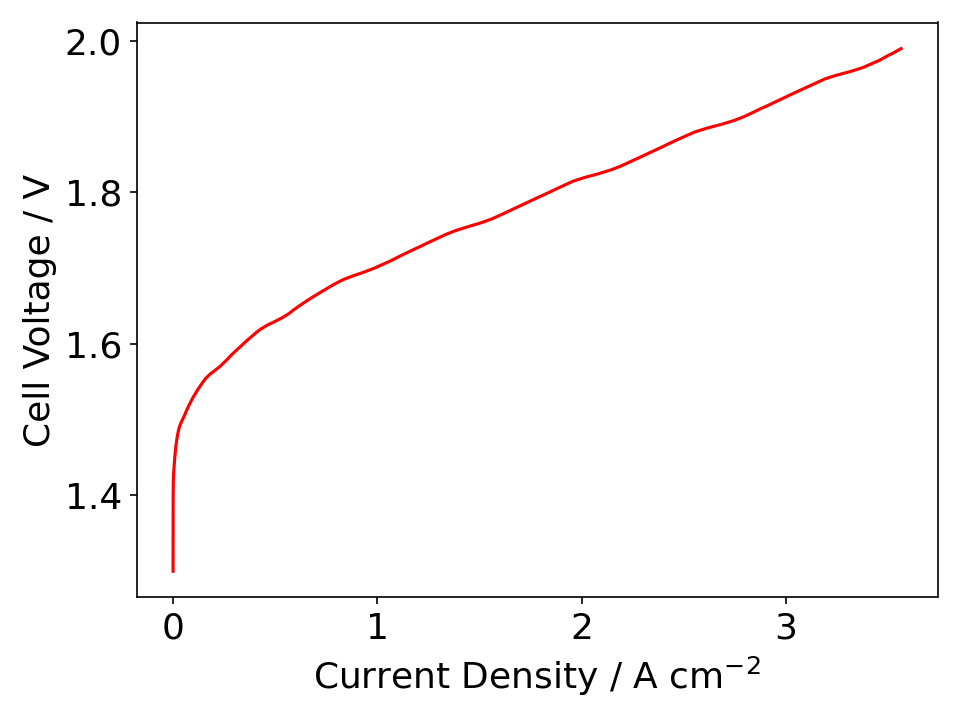

In [36]:
name1='day1_test_SV'

fig = plt.figure()
ax = fig.add_subplot()

#number of smaple
i=0

ax.plot(processed_data[i][0][:, 8] / (area * 1000), processed_data[i][0][:, 7], label=labels[0] + 'Day 1', color='red')

ax.set_ylabel('Cell Voltage / V')
ax.set_xlabel('Current Density / A cm$^{-2}$')

plt.savefig(path_OUT+'\\'+name+'.png', transparent=True,bbox_inches="tight")
plt.tight_layout()
plt.show()